#### Be carefull with this notebook, there are cell that takes a lot time execution. 

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import numpy as np
import multimin as mm
from tqdm import tqdm
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    trasformation_E_to_X,
    hypercube_surface_integral_P_X_CMND
    )

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

C:\Users\aguju\Documents\tesis\juanita\juanita\repo_public\quasiNEA\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


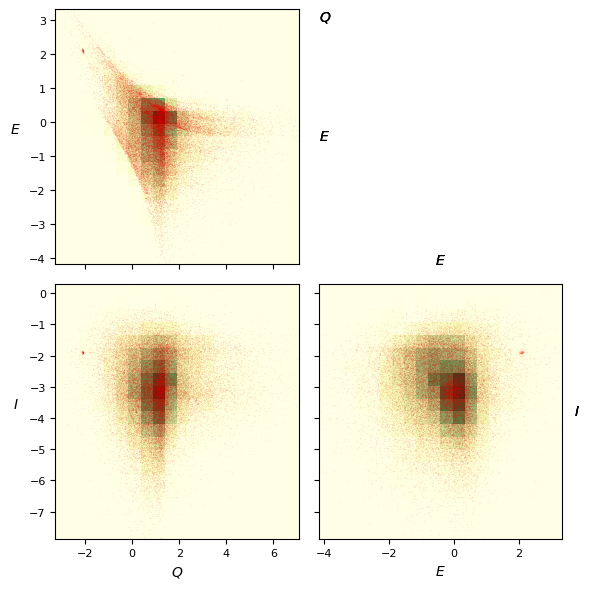

In [3]:
F = mm.FitCMND(f"../orbital_elements_cmnd/products/fit-NEAS-Ngauss10.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [ ]:
N = int(1e7)
fit_sample = F.cmnd.rvs(Nsam=N)

In [ ]:
scales=[1.35,1.00,np.pi]
converted_sample = np.zeros_like(fit_sample)
for i, element in enumerate(fit_sample):
    converted_sample[i] = mm.Util.tIF(element, scales, mm.Util.u2f)

converted_sample

In [ ]:
q_CMND = converted_sample[:,0]
e_CMND = converted_sample[:,1]
i_CMND = converted_sample[:,2]

Omega_uniform = np.random.uniform(0, 2*np.pi, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)

elements = np.column_stack((q_CMND, e_CMND, i_CMND, Omega_uniform, w_uniform, M_uniform))

state_vectors = np.zeros((N, 6))
for el in tqdm(range(N)):
    q = q_CMND[el]
    e = e_CMND[el]
    i = i_CMND[el]
    Omega = Omega_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]

    x, y, z, vx, vy, vz = trasformation_E_to_X(q, e, i, Omega, w, M, mu)
    state_vectors[el] = np.array([x, y, z, vx, vy, vz])

In [ ]:
#max elements
max_elements = (1.35, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = hypercube_surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)